In [1]:
# STEP 1: Load all the data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import os

# Set working directory
os.chdir(r"C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/sleep_python/scripts/")

# Load sleep architecture arrays
wt_light_on_arch = np.load('sleep_architecture_outputs/wt_light_on_sleep_metrics.npy')
wt_light_off_arch = np.load('sleep_architecture_outputs/wt_light_off_sleep_metrics.npy')
hom_light_on_arch = np.load('sleep_architecture_outputs/hom_light_on_sleep_metrics.npy')
hom_light_off_arch = np.load('sleep_architecture_outputs/hom_light_off_sleep_metrics.npy')


print("Loaded sleep architecture arrays:")
print(f"WT light on: {len(wt_light_on_arch)} mice")
print(f"WT light off: {len(wt_light_off_arch)} mice")
print(f"HOM light on: {len(hom_light_on_arch)} mice")
print(f"HOM light off: {len(hom_light_off_arch)} mice")


Loaded sleep architecture arrays:
WT light on: 6 mice
WT light off: 6 mice
HOM light on: 8 mice
HOM light off: 8 mice


In [2]:
# Step 2: Generate Supplementary Table 1: WT and HOM individual NREM total time with metadata
import pandas as pd

wt_metadata = [
    {'ID': 'WT01', 'Sex': 'F', 'Age (months)': 12},  # WT03
    {'ID': 'WT02', 'Sex': 'M', 'Age (months)': 9},   # WT04
    {'ID': 'WT03', 'Sex': 'M', 'Age (months)': 9},   # WT05
    {'ID': 'WT04', 'Sex': 'F', 'Age (months)': 8},   # WT06
    {'ID': 'WT05', 'Sex': 'M', 'Age (months)': 9},   # WT07
    {'ID': 'WT06', 'Sex': 'M', 'Age (months)': 8},   # WT08
]

hom_metadata = [
    {'ID': 'Q331K01', 'Sex': 'F', 'Age (months)': 13},  # HOM01
    {'ID': 'Q331K02', 'Sex': 'M', 'Age (months)': 14},  # HOM02
    {'ID': 'Q331K03', 'Sex': 'M', 'Age (months)': 10},  # HOM03
    {'ID': 'Q331K04', 'Sex': 'M', 'Age (months)': 12},  # HOM04
    {'ID': 'Q331K05', 'Sex': 'M', 'Age (months)': 9},   # HOM05
    {'ID': 'Q331K06', 'Sex': 'M', 'Age (months)': 9},   # HOM06
    {'ID': 'Q331K07', 'Sex': 'F', 'Age (months)': 9},   # HOM07
    {'ID': 'Q331K08', 'Sex': 'F', 'Age (months)': 8},   # HOM10
]

rows = []
for meta, on, off in zip(wt_metadata, wt_light_on_arch, wt_light_off_arch):
    rows.append({
        'ID': meta['ID'],
        #'Genotype': 'WT',
        'Sex': meta['Sex'],
        'Age (months)': meta['Age (months)'],
        'NREM Total Time Light ON (min)': round(on['NREM_total_time'], 2),
        'NREM Total Time Light OFF (min)': round(off['NREM_total_time'], 2),
    })

for meta, on, off in zip(hom_metadata, hom_light_on_arch, hom_light_off_arch):
    rows.append({
        'ID': meta['ID'],
        #'Genotype': 'HOM',
        'Sex': meta['Sex'],
        'Age (months)': meta['Age (months)'],
        'NREM Total Time Light ON (min)': round(on['NREM_total_time'], 2),
        'NREM Total Time Light OFF (min)': round(off['NREM_total_time'], 2),
    })

nrem_table = pd.DataFrame(rows)
print(nrem_table.to_string(index=False))

# Save table 
output_dir = r"C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/Sleep_paper/figures/"
nrem_table.to_csv(output_dir + 'Supplementary_Table_1_NREM_individual.csv', index=False)
nrem_table.to_excel(output_dir + 'Supplementary_Table_1_NREM_individual.xlsx', index=False)
print("Table saved.")

     ID Sex  Age (months)  NREM Total Time Light ON (min)  NREM Total Time Light OFF (min)
   WT01   F            12                      142.830002                        96.000000
   WT02   M             9                      129.830002                       105.669998
   WT03   M             9                      135.830002                        98.000000
   WT04   F             8                      133.500000                        92.830002
   WT05   M             9                      147.330002                        91.169998
   WT06   M             8                      158.669998                       122.669998
Q331K01   F            13                      152.000000                       114.169998
Q331K02   M            14                      131.500000                       127.830002
Q331K03   M            10                      128.830002                       118.500000
Q331K04   M            12                      129.000000                       122.500000

In [3]:
# Step 3: Identify outliers in NREM total time and NREM bout duration with metadata

# HOM mice: NREM Total Time at Light ON and Light OFF with metadata
import numpy as np

hom_metadata = [
    {'id': 'HOM01', 'sex': 'F', 'age': 13},
    {'id': 'HOM02', 'sex': 'M', 'age': 14},
    {'id': 'HOM03', 'sex': 'M', 'age': 10},
    {'id': 'HOM04', 'sex': 'M', 'age': 12},
    {'id': 'HOM05', 'sex': 'M', 'age': 9},
    {'id': 'HOM06', 'sex': 'M', 'age': 9},
    {'id': 'HOM07', 'sex': 'F', 'age': 9},
    {'id': 'HOM10', 'sex': 'F', 'age': 8},
]

print(f"{'ID':<8} {'Sex':<5} {'Age':<5} {'NREM Total Time ON':>20} {'NREM Total Time OFF':>20}")
print("-" * 60)

for meta, on, off in zip(hom_metadata, hom_light_on_arch, hom_light_off_arch):
    print(f"{meta['id']:<8} {meta['sex']:<5} {meta['age']:<5} "
          f"{on['NREM_total_time']:>20.2f} {off['NREM_total_time']:>20.2f}")

ID       Sex   Age     NREM Total Time ON  NREM Total Time OFF
------------------------------------------------------------
HOM01    F     13                  152.00               114.17
HOM02    M     14                  131.50               127.83
HOM03    M     10                  128.83               118.50
HOM04    M     12                  129.00               122.50
HOM05    M     9                   146.83                71.17
HOM06    M     9                   153.50               132.33
HOM07    F     9                   136.00               122.17
HOM10    F     8                   136.17                68.00


In [4]:
# STEP 4: Organize data into a single DataFrame for plotting

# Input: wt/hom_light_on/off_arch = arrays of per-mouse dicts, each holding that mouse's sleep architecture metrics (transition counts, bout counts, 
# mean durations, total times) for one genotype/light condition


def create_combined_dataframe():
    measures = {
        'NREM_to_REM_trans':  'NREM_to_REM_transitions',
        'Wake_to_NREM_trans': 'Wake_to_NREM_transitions',
        'REM_to_Wake_trans':  'REM_to_Wake_transitions',
        'NREM_count':         'NREM_count',
        'NREM_duration':      'NREM_mean_duration',
        'NREM_total_time':    'NREM_total_time',
        'REM_count':          'REM_count',
        'REM_duration':       'REM_mean_duration',
        'REM_total_time':     'REM_total_time',
    }
    # array -> (genotype, condition)
    sources = [
        (wt_light_on_arch,  'WT',  'Light ON'),
        (wt_light_off_arch, 'WT',  'Light OFF'),
        (hom_light_on_arch, 'HOM', 'Light ON'),
        (hom_light_off_arch,'HOM', 'Light OFF'),
    ]
    data_rows = []
    for arr, geno, cond in sources:
        for mouse in arr:
            for label, key in measures.items():
                data_rows.append({'genotype': geno, 'condition': cond,
                                  'measure': label, 'value': mouse[key]})
    return pd.DataFrame(data_rows)

plot_data = create_combined_dataframe()
print("\nCombined data shape:", plot_data.shape)
print("\nUnique measures:", plot_data['measure'].unique())
print(plot_data.head(20))


Combined data shape: (252, 4)

Unique measures: ['NREM_to_REM_trans' 'Wake_to_NREM_trans' 'REM_to_Wake_trans' 'NREM_count'
 'NREM_duration' 'NREM_total_time' 'REM_count' 'REM_duration'
 'REM_total_time']
   genotype condition             measure       value
0        WT  Light ON   NREM_to_REM_trans   17.000000
1        WT  Light ON  Wake_to_NREM_trans   41.000000
2        WT  Light ON   REM_to_Wake_trans   14.000000
3        WT  Light ON          NREM_count   41.000000
4        WT  Light ON       NREM_duration    3.365854
5        WT  Light ON     NREM_total_time  142.833328
6        WT  Light ON           REM_count   17.000000
7        WT  Light ON        REM_duration    1.431373
8        WT  Light ON      REM_total_time   27.000000
9        WT  Light ON   NREM_to_REM_trans   11.000000
10       WT  Light ON  Wake_to_NREM_trans   34.000000
11       WT  Light ON   REM_to_Wake_trans    7.000000
12       WT  Light ON          NREM_count   34.000000
13       WT  Light ON       NREM_durati

In [7]:
# STEP 5: Run Mixed ANOVAs for all sleep architecture measures
import pingouin as pg
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

def get_significance_stars(p_value):
    """Convert p-value to significance stars"""
    if p_value < 0.001: return '***'
    elif p_value < 0.01: return '**'
    elif p_value < 0.05: return '*'
    else: return 'ns'

# Input: same per-mouse metric dicts as Step 4
def create_stats_dataframe():
    measures_map = {
        'NREM_count': 'NREM_count', 'NREM_duration': 'NREM_mean_duration',
        'NREM_total_time': 'NREM_total_time', 'REM_count': 'REM_count',
        'REM_duration': 'REM_mean_duration', 'REM_total_time': 'REM_total_time',
        'NREM_to_REM_trans': 'NREM_to_REM_transitions',
        'Wake_to_NREM_trans': 'Wake_to_NREM_transitions',
        'REM_to_Wake_trans': 'REM_to_Wake_transitions',
    }
    sources = [
        (wt_light_on_arch,  'WT',  'Light ON'),
        (wt_light_off_arch, 'WT',  'Light OFF'),
        (hom_light_on_arch, 'HOM', 'Light ON'),
        (hom_light_off_arch,'HOM', 'Light OFF'),
    ]
    data_rows = []
    for arr, geno, cond in sources:
        for i, mouse in enumerate(arr, start=1):
            row = {'mouse': f'{geno}{i}', 'genotype': geno, 'condition': cond}
            row.update({label: mouse[key] for label, key in measures_map.items()})
            data_rows.append(row)
    return pd.DataFrame(data_rows)

stats_df = create_stats_dataframe()
print("Stats dataframe created:")
print(stats_df.head())
print(f"\nTotal rows: {len(stats_df)}")

# Measures to test and display names
measures = [
    'NREM_to_REM_trans', 'Wake_to_NREM_trans', 'REM_to_Wake_trans',
    'NREM_count', 'REM_count', 'NREM_duration', 'REM_duration',
    'NREM_total_time', 'REM_total_time'
]
measure_names = [
    'NREM→REM Transitions', 'Wake→NREM Transitions', 'REM→Wake Transitions',
    'NREM Bout Count', 'REM Bout Count', 'NREM Bout Duration', 'REM Bout Duration',
    'Total NREM Time', 'Total REM Time'
]

# Run mixed ANOVA for each measure
anova_results = {}
for measure, name in zip(measures, measure_names):
    aov = pg.mixed_anova(data=stats_df, dv=measure, within='condition',
                         between='genotype', subject='mouse')
    anova_results[measure] = aov
    print(f"\n{'='*70}\nMIXED ANOVA FOR: {name}\n{'='*70}")
    print(aov)

# Significance summary
print("\n" + "="*80)
print("SIGNIFICANCE SUMMARY - ALL MEASURES")
print("="*80)
print(f"{'Measure':<30} {'Genotype':<15} {'Condition':<15} {'Interaction':<15}")
print("-"*80)
for measure, name in zip(measures, measure_names):
    aov = anova_results[measure]
    geno_p  = aov[aov['Source'] == 'genotype']['p-unc'].values[0]
    cond_p  = aov[aov['Source'] == 'condition']['p-unc'].values[0]
    inter_p = aov[aov['Source'] == 'Interaction']['p-unc'].values[0]
    print(f"{name:<30} {geno_p:.4f} {get_significance_stars(geno_p):<10} "
          f"{cond_p:.4f} {get_significance_stars(cond_p):<10} "
          f"{inter_p:.4f} {get_significance_stars(inter_p):<10}")

Stats dataframe created:
  mouse genotype condition  NREM_count  NREM_duration  NREM_total_time  REM_count  REM_duration  REM_total_time  NREM_to_REM_trans  Wake_to_NREM_trans  REM_to_Wake_trans
0   WT1       WT  Light ON          41       3.365854       142.833328         17      1.431373       27.000000                 17                  41                 14
1   WT2       WT  Light ON          34       3.578431       129.833328         11      1.333333       17.666666                 11                  34                  7
2   WT3       WT  Light ON          42       3.154762       135.833328         20      1.133333       24.833334                 20                  42                 11
3   WT4       WT  Light ON          24       5.555555       133.500000         11      1.681818       20.166666                 11                  24                 10
4   WT5       WT  Light ON          34       4.063725       147.333328         17      1.225490       22.333334              

In [8]:
# STEP 6: Create a table that contains all poutput from Step 5 (ANOVA) (could be used in for supplementary materials?)
import pandas as pd

# Calculate descriptive statistics
desc_rows = []
for measure, name in zip(measures, measure_names):
    for genotype in ['WT', 'HOM']:
        for condition in ['Light ON', 'Light OFF']:
            subset = stats_df[(stats_df['genotype'] == genotype) & (stats_df['condition'] == condition)]
            desc_rows.append({
                'Measure': name,
                'Genotype': genotype,
                'Condition': condition,
                'N': len(subset),
                'Mean ± SD': f"{subset[measure].mean():.2f} ± {subset[measure].std():.2f}"
            })

descriptive_table = pd.DataFrame(desc_rows)

# Create ANOVA summary with F-statistics and df
anova_rows = []
for measure, name in zip(measures, measure_names):
    aov = anova_results[measure]
    
    # Extract genotype results
    geno_row = aov[aov['Source'] == 'genotype']
    geno_f = geno_row['F'].values[0]
    geno_df1 = int(geno_row['DF1'].values[0])
    geno_df2 = int(geno_row['DF2'].values[0])
    geno_p = geno_row['p-unc'].values[0]
    
    # Extract condition results
    cond_row = aov[aov['Source'] == 'condition']
    cond_f = cond_row['F'].values[0]
    cond_df1 = int(cond_row['DF1'].values[0])
    cond_df2 = int(cond_row['DF2'].values[0])
    cond_p = cond_row['p-unc'].values[0]
    
    # Extract interaction results
    inter_row = aov[aov['Source'] == 'Interaction']
    inter_f = inter_row['F'].values[0]
    inter_df1 = int(inter_row['DF1'].values[0])
    inter_df2 = int(inter_row['DF2'].values[0])
    inter_p = inter_row['p-unc'].values[0]
    
    anova_rows.append({
        'Measure': name,
        'Genotype F': f"F({geno_df1},{geno_df2})={geno_f:.2f}",
        'Genotype p': "< 0.001" if geno_p < 0.001 else f"{geno_p:.3f}",
        'Genotype Sig': get_significance_stars(geno_p),
        'Condition F': f"F({cond_df1},{cond_df2})={cond_f:.2f}",
        'Condition p': "< 0.001" if cond_p < 0.001 else f"{cond_p:.3f}",
        'Condition Sig': get_significance_stars(cond_p),
        'Interaction F': f"F({inter_df1},{inter_df2})={inter_f:.2f}",
        'Interaction p': "< 0.001" if inter_p < 0.001 else f"{inter_p:.3f}",
        'Interaction Sig': get_significance_stars(inter_p)
    })

anova_summary_table = pd.DataFrame(anova_rows)

# Print and save
print("\nDESCRIPTIVE STATISTICS:")
print(descriptive_table.to_string(index=False))
print("\n\nANOVA RESULTS:")
print(anova_summary_table.to_string(index=False))

# Save to CSV
import os
output_dir = r"C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/Sleep_paper/figures/"
os.makedirs(output_dir, exist_ok=True)
descriptive_table.to_csv(os.path.join(output_dir, 'fig_2_descriptive_stats.csv'), index=False)
anova_summary_table.to_csv(os.path.join(output_dir, 'fig_2_ANOVA_results.csv'), index=False)
print(f"\nTables saved to: {output_dir}")


DESCRIPTIVE STATISTICS:
              Measure Genotype Condition  N      Mean ± SD
 NREM→REM Transitions       WT  Light ON  6   15.00 ± 3.63
 NREM→REM Transitions       WT Light OFF  6    6.67 ± 0.82
 NREM→REM Transitions      HOM  Light ON  8   13.50 ± 1.93
 NREM→REM Transitions      HOM Light OFF  8   10.75 ± 3.33
Wake→NREM Transitions       WT  Light ON  6   34.33 ± 6.65
Wake→NREM Transitions       WT Light OFF  6   24.00 ± 4.15
Wake→NREM Transitions      HOM  Light ON  8   36.50 ± 7.25
Wake→NREM Transitions      HOM Light OFF  8   24.00 ± 4.72
 REM→Wake Transitions       WT  Light ON  6    8.33 ± 4.23
 REM→Wake Transitions       WT Light OFF  6    6.67 ± 1.97
 REM→Wake Transitions      HOM  Light ON  8    6.12 ± 4.61
 REM→Wake Transitions      HOM Light OFF  8    5.50 ± 4.00
      NREM Bout Count       WT  Light ON  6   34.33 ± 6.65
      NREM Bout Count       WT Light OFF  6   24.00 ± 4.15
      NREM Bout Count      HOM  Light ON  8   36.50 ± 7.25
      NREM Bout Count      HOM 

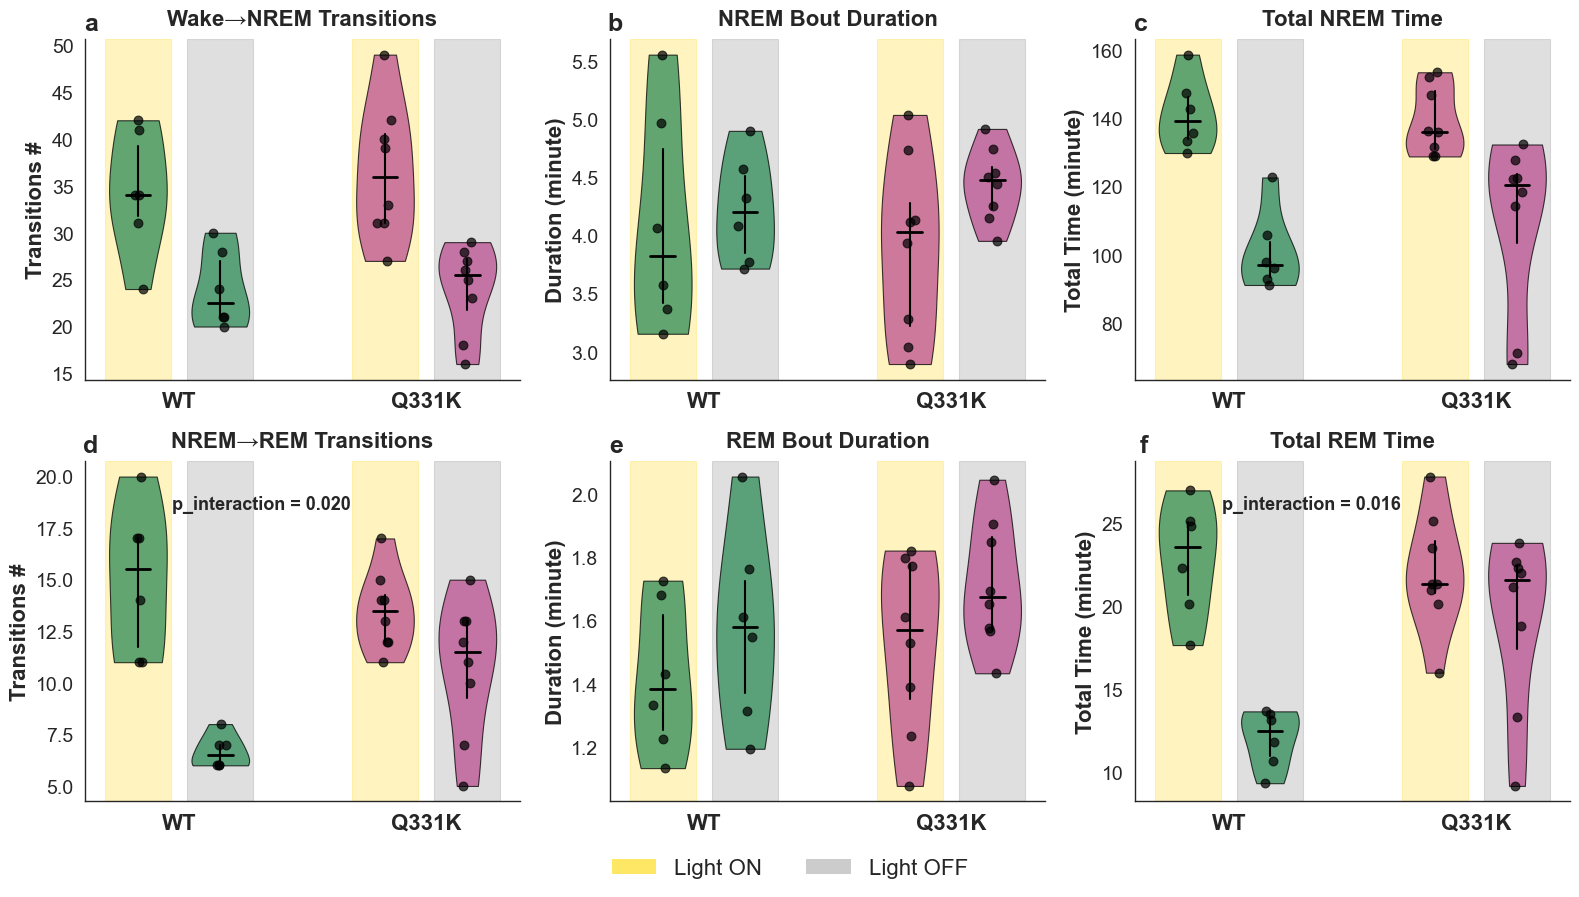

In [27]:
# STEP 7: Create 6-panel figure (2 rows x 3 columns) with significance stars

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import os

sns.set_style("white")
sns.set_context("paper", font_scale=1.4)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = {'WT': '#2E8B57', 'Q331K': '#BC5090'}
cond_bg = {'Light ON': '#FFD700', 'Light OFF': '#808080'}

plot_measures = [
    'Wake_to_NREM_trans', 'NREM_duration', 'NREM_total_time',
    'NREM_to_REM_trans',  'REM_duration',  'REM_total_time'
]
plot_labels_title = [
    'Wake→NREM Transitions', 'NREM Bout Duration', 'Total NREM Time',
    'NREM→REM Transitions',  'REM Bout Duration',  'Total REM Time'
]
plot_labels_ylabel = [
    'Transitions #', 'Duration (minute)', 'Total Time (minute)',
    'Transitions #', 'Duration (minute)', 'Total Time (minute)'
]

for idx, (measure, label_title, label_ylabel) in enumerate(
        zip(plot_measures, plot_labels_title, plot_labels_ylabel)):
    ax = axes[idx]
    measure_data = plot_data[plot_data['measure'] == measure].copy()
    measure_data['genotype'] = measure_data['genotype'].replace('HOM', 'Q331K')

    order = [('WT', 'Light ON'), ('WT', 'Light OFF'),
             ('Q331K', 'Light ON'), ('Q331K', 'Light OFF')]
    positions = [0, 1, 3, 4]

    data_list = [
        measure_data[(measure_data['genotype'] == g) &
                     (measure_data['condition'] == c)]['value'].values
        for g, c in order
    ]

    # Add condition background shading FIRST (zorder=0, behind everything)
    for (geno, cond), pos in zip(order, positions):
        ax.axvspan(pos - 0.4, pos + 0.4,
                   color=cond_bg[cond],
                   alpha=0.25,
                   zorder=0)

    # Violin plots
    parts = ax.violinplot(
        data_list, positions=positions, widths=0.7,
        showmeans=False, showmedians=False, showextrema=False
    )

    for i, (pc, (geno, cond)) in enumerate(zip(parts['bodies'], order)):
        pc.set_facecolor(colors[geno])
        pc.set_edgecolor('black')
        pc.set_linewidth(0.8)
        pc.set_alpha(0.75)
        pc.set_zorder(2)

    # Individual points and quartiles
    for (geno, cond), pos, data in zip(order, positions, data_list):
        jitter = np.random.normal(pos, 0.04, len(data))
        ax.scatter(jitter, data,
                   color='black', s=40, zorder=3, alpha=0.7)
        if len(data) > 0:
            q1, median, q3 = np.percentile(data, [25, 50, 75])
            ax.plot([pos-0.15, pos+0.15], [median, median], 'k-', linewidth=2, zorder=4)
            ax.plot([pos, pos], [q1, q3], 'k-', linewidth=1.5, zorder=4)

     # Significance annotation: interaction p-value (only if significant)
    aov = anova_results[measure]
    inter_p = aov[aov['Source'] == 'Interaction']['p-unc'].values[0]
    if inter_p < 0.05:
        p_str = "p_int < 0.001" if inter_p < 0.001 else f"p_interaction = {inter_p:.3f}"
        ax.text(0.2, 0.90, p_str, transform=ax.transAxes,
                ha='left', va='top', fontsize=13, fontweight='bold')

    
    # Formatting
    ax.set_xticks([0.5, 3.5])
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticklabels(['WT', 'Q331K'], fontsize=16, fontweight='bold')
    ax.set_ylabel(label_ylabel, fontsize=16, fontweight='bold')
    ax.set_title(label_title, fontweight='bold', pad=10, fontsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.text(0.03, 1.08, 'abcdef'[idx], transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='right')

    
    # Legend on first panel only
    if idx == 5:
        legend_elements = [
            Patch(facecolor='#FFD700', edgecolor='none', alpha=0.6, label='Light ON'),
            Patch(facecolor='#C0C0C0', edgecolor='none', alpha=0.8, label='Light OFF'),
        ]
        fig.legend(handles=legend_elements, loc='lower center', ncol=2,
                   frameon=False, fontsize=16, bbox_to_anchor=(0.5, -0.02)) 

        

plt.tight_layout(rect=[0, 0.03, 1, 0.99])

# for col, txt in zip([0,1,2], ['Transitions #','Duration (minute)','Total Time (minute)']):
#     pos_top = axes[col].get_position()
#     pos_bot = axes[col+3].get_position()
#     fig.text(pos_top.x0 - 0.035, (pos_top.y1 + pos_bot.y0)/2, txt,
#              rotation=90, va='center', ha='center', fontsize=16, fontweight='bold')
    
output_dir = r"C:/Users/cigde/Dropbox/PDC_Projects/Jemeen/Sleep_paper/figures/"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'fig2_sleep_architecture.tiff'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(output_dir, 'fig2_sleep_architecture.pdf'), bbox_inches='tight')
plt.show()